# Algoritmo de la colonia de hormigas para Optimización
Implementación para resolver el problema del viajero utilizando rastros de feromonas y distancias.

In [1]:
import random, sys, math

# Genera una matriz de distancias de nCiudades x nCiudades
def matrizDistancias(nCiud, distanciaMaxima):
    matriz = [[0 for i in range(nCiud)] for j in range(nCiud)]
    for i in range(nCiud):
        for j in range(i):
            matriz[i][j] = distanciaMaxima * random.random()
            matriz[j][i] = matriz[i][j]
    return matriz

# Elige un paso de una hormiga, teniendo en cuenta las distancias
# y las feromonas y descartando las ciudades ya visitadas.
def eligeCiudad(dists, ferom, visitadas):
    listaPesos = []
    disponibles = []
    actual = visitadas[-1]
    
    # Influencia de cada valor (alfa: feromonas; beta: distancias)
    alfa = 1.0
    beta = 0.5
    
    for i in range(len(dists)):
        if i not in visitadas:
            fer = math.pow((1.0 + ferom[actual][i]), alfa)
            peso = math.pow(1.0 / dists[actual][i], beta) * fer
            disponibles.append(i)
            listaPesos.append(peso)
            
    # Se elige aleatoriamente una de las ciudades disponibles,
    # teniendo en cuenta su peso relativo.
    valor = random.random() * sum(listaPesos)
    acumulado = 0.0
    i = -1
    while valor > acumulado:
        i += 1
        acumulado += listaPesos[i]
    return disponibles[i]

In [2]:
# Genera una "hormiga", que elegirá un camino teniendo en cuenta
# las distancias y los rastros de feromonas. Devuelve una tupla
# con el camino y su longitud. La ciudad inicial siempre es la 0.
def eligeCamino(distancias, feromonas):
    camino = [0]
    longCamino = 0
    # Elegir cada paso según la distancia y las feromonas
    while len(camino) < len(distancias):
        ciudad = eligeCiudad(distancias, feromonas, camino)
        longCamino += distancias[camino[-1]][ciudad]
        camino.append(ciudad)
    # Para terminar hay que volver a la ciudad de origen (0)
    longCamino += distancias[camino[-1]][0]
    camino.append(0)
    return (camino, longCamino)

# Actualiza la matriz de feromonas siguiendo el camino recibido
def rastroFeromonas(feromonas, camino, dosis):
    for i in range(len(camino) - 1):
        feromonas[camino[i]][camino[i+1]] += dosis

# Evapora todas las feromonas multiplicándolas por una constante
# (en este caso el coeficiente de evaporación es 0.1)
def evaporaFeromonas(feromonas):
    for lista in feromonas:
        for i in range(len(lista)):
            lista[i] *= 0.9

In [3]:
# Resuelve el problema del viajante de comercio mediante el
# algoritmo de la colonia de hormigas. Recibe una matriz de
# distancias y devuelve una tupla con el mejor camino que ha
# obtenido (lista de índices) y su longitud
def hormigas(distancias, iteraciones, distMedia):
    n = len(distancias)
    feromonas = [[0 for i in range(n)] for j in range(n)]
    mejorCamino = []
    longMejorCamino = sys.maxsize
    
    # En cada iteración se genera una hormiga, que elige un camino,
    # y si es mejor que el mejor que teníamos, deja su rastro de
    # feromonas (mayor cuanto más corto sea el camino)
    for iter in range(iteraciones):
        (camino, longCamino) = eligeCamino(distancias, feromonas)
        if longCamino <= longMejorCamino:
            mejorCamino = camino
            longMejorCamino = longCamino
            rastroFeromonas(feromonas, camino, distMedia/longCamino)
        # En cualquier caso, las feromonas se van evaporando
        evaporaFeromonas(feromonas)
    return (mejorCamino, longMejorCamino)

In [4]:
# Generación de una matriz de prueba
numCiudades = 10
distanciaMaxima = 10
ciudades = matrizDistancias(numCiudades, distanciaMaxima)

# Obtención del mejor camino
iteraciones = 1000
distMedia = numCiudades * distanciaMaxima / 2
(camino, longCamino) = hormigas(ciudades, iteraciones, distMedia)

print("Camino:", camino)
print("Longitud del camino:", longCamino)

Camino: [0, 9, 8, 4, 2, 1, 5, 6, 3, 7, 0]
Longitud del camino: 16.38153455358924


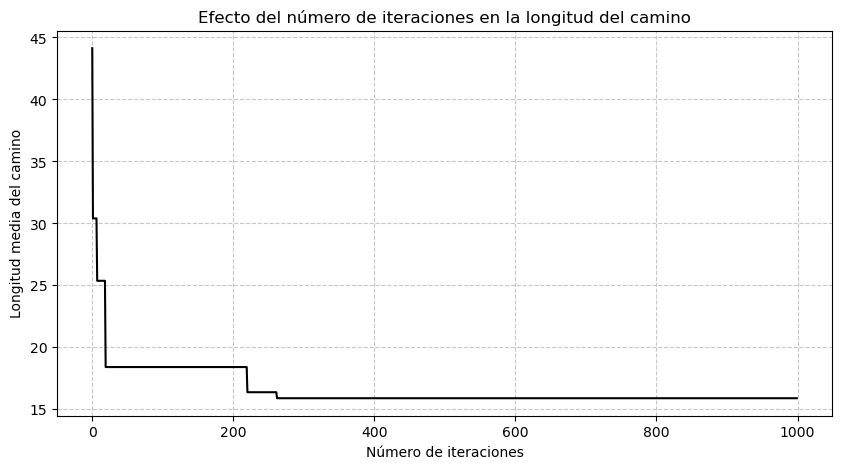

In [5]:
import matplotlib.pyplot as plt

# Modificación ligera a la función para guardar el historial y graficar la convergencia
def hormigas_con_historial(distancias, iteraciones, distMedia):
    n = len(distancias)
    feromonas = [[0 for i in range(n)] for j in range(n)]
    mejorCamino = []
    longMejorCamino = sys.maxsize
    historial = []
    
    for iter in range(iteraciones):
        (camino, longCamino) = eligeCamino(distancias, feromonas)
        if longCamino <= longMejorCamino:
            mejorCamino = camino
            longMejorCamino = longCamino
            rastroFeromonas(feromonas, camino, distMedia/longCamino)
        evaporaFeromonas(feromonas)
        historial.append(longMejorCamino) # Guardar para la gráfica
        
    return (mejorCamino, longMejorCamino, historial)

# Ejecución
(camino, longCamino, historial) = hormigas_con_historial(ciudades, iteraciones, distMedia)

# Gráfica de convergencia (Iteraciones vs Longitud del camino)
plt.figure(figsize=(10, 5))
plt.plot(range(iteraciones), historial, color='black')
plt.title('Efecto del número de iteraciones en la longitud del camino')
plt.xlabel('Número de iteraciones')
plt.ylabel('Longitud media del camino')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# El Problema del Viajero (Traveling Salesman Problem)

## Descripción general
El problema del viajante de comercio es uno de los problemas fundamentales en las ciencias de la computación y la investigación de operaciones. Consiste en encontrar la ruta más corta posible que visite un conjunto de ciudades dadas exactamente una vez y regrese al punto de origen.

## Objetivos
* Minimizar la distancia total, el costo o el tiempo de recorrido del viaje completo.
* Encontrar rutas eficientes en escenarios complejos, lo cual tiene aplicaciones directas en logística, diseño de microchips y planificación.

## Limitaciones
* Es un problema clasificado como **NP-difícil (NP-hard)**. Esto significa que a medida que aumenta el número de ciudades, la cantidad de rutas posibles crece de forma factorial.
* Para un número elevado de ciudades, es computacionalmente inviable encontrar la solución perfecta (exacta) evaluando todas las combinaciones posibles en un tiempo razonable.

## Trabajos previos y enfoques de solución
A lo largo de la historia se han propuesto diferentes métodos para abordarlo empíricamente. En lugar de buscar la solución perfecta, se utilizan técnicas heurísticas y metaheurísticas:

* [cite_start]**Algoritmo de la colonia de hormigas:** Resuelve el problema del viajante de comercio mediante un enfoque iterativo[cite: 167]. [cite_start]Genera "hormigas" que eligen caminos teniendo en cuenta las distancias y los rastros de feromonas[cite: 107, 108]. [cite_start]Si el camino es mejor, las hormigas dejan un rastro de feromonas mayor cuanto más corto sea el recorrido, al tiempo que estas feromonas se van evaporando progresivamente[cite: 151, 198].
* [cite_start]**Optimización con enjambres de partículas:** Este método utiliza un conjunto de soluciones candidatas que se comportan como partículas moviéndose por un espacio de soluciones[cite: 238]. [cite_start]El movimiento de las partículas se determina por su velocidad, que depende de la posición del mejor punto que ha encontrado cada una de ellas en su recorrido y del mejor punto encontrado globalmente por el enjambre[cite: 239].